# Part 2 — Unbatched vs Half Batch vs Full Batch

**Question:** what's the cost / accuracy trade-off as we collapse the value evaluator's call shape?

* `unbatched` (paper-strict) — 1 call per testable clue per sibling.
* `half_basic` — 1 call per sibling, all clues batched in.
* `full_basic` — 1 call total per DFS step, all siblings × clues batched in.

**Data:** 5 runs per level on the 20-puzzle paper split. One half-batch file is partial (n=8) and excluded from means.

In [1]:
import json, glob, statistics
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Walk up from cwd to the repo root (where 'results/' and 'data/' live).
# Robust to Jupyter being launched from the notebook dir or the repo root.
ROOT = Path.cwd().resolve()
while not ((ROOT / 'results').is_dir() and (ROOT / 'data').is_dir()):
    if ROOT == ROOT.parent:
        raise RuntimeError(f"can't find repo root from {Path.cwd()}")
    ROOT = ROOT.parent
RUNS = ROOT / 'results' / 'crosswords' / 'runs'
assert RUNS.is_dir()

# ---------------- Report palette ----------------
CHARCOAL = '#233d4d'   # primary dark
PUMPKIN  = '#fe7f2d'   # accent / highlight
GOLDEN   = '#fcca46'   # warm secondary
OLIVE    = '#a1c181'   # muted secondary
SEAGRASS = '#619b8a'   # cool secondary

# Per-level colors used everywhere in this notebook.
LEVEL_COLOR = {
    'Unbatched':  CHARCOAL,
    'Half batch': SEAGRASS,
    'Full batch': PUMPKIN,
}

mpl.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.edgecolor':CHARCOAL,'axes.labelcolor':CHARCOAL,'axes.titlecolor':CHARCOAL,
    'axes.titleweight':'bold','axes.labelweight':'bold',
    'axes.titlesize':14,'axes.labelsize':12,'axes.linewidth':1.6,
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':False,
    'xtick.color':CHARCOAL,'ytick.color':CHARCOAL,
    'xtick.labelsize':11,'ytick.labelsize':11,
    'xtick.major.size':0,'ytick.major.size':4,
    'font.weight':'bold','font.family':'sans-serif',
    'legend.frameon':False,'legend.fontsize':11,
    'lines.linewidth':2.6,'lines.markersize':9,
    'savefig.dpi':180,'savefig.bbox':'tight',
})

## 1. Helpers — same metrics as `analyze.py`

In [2]:
def grid_metrics(grid, gt):
    flat = [c.upper() for r in grid for c in r]
    truth = [c.upper() for c in gt]
    if len(flat) != 25: return 0.0, 0.0, 0.0
    cl = sum(1 for o, t in zip(flat, truth) if o == t)
    cw = sum(1 for i in range(5) if flat[i*5:(i+1)*5] == truth[i*5:(i+1)*5])
    cw += sum(1 for i in range(5) if flat[i::5] == truth[i::5])
    return cl/25, cw/10, 1.0 if cl == 25 else 0.0

def load_runs(pattern, drop_partial=True, expected_n=20):
    """Return list of {file, rows} for files matching pattern.
    Files with len(rows) < expected_n are dropped when drop_partial is True."""
    out = []
    for fp in sorted(glob.glob(str(RUNS/pattern))):
        with open(fp) as f:
            rows = [json.loads(line) for line in f if line.strip()]
        if drop_partial and len(rows) < expected_n:
            continue
        out.append({'file': Path(fp).name, 'rows': rows})
    return out

def run_metrics(rows):
    """Per-run aggregate. Returns (letter%, word%, game%, mean_steps, mean_calls, mean_secs)."""
    Ls, Ws, Gs, Ss, Cs, Ts = [], [], [], [], [], []
    for r in rows:
        l, w, g = grid_metrics(r['grid'], r['ground_truth'])
        Ls.append(l); Ws.append(w); Gs.append(g)
        Ss.append(r.get('expansions', 0))
        Cs.append(r.get('llm_calls_total', 0))
        Ts.append(r.get('runtime_sec', r.get('elapsed_s', 0)))
    return {
        'letter': statistics.mean(Ls)*100,
        'word':   statistics.mean(Ws)*100,
        'game':   statistics.mean(Gs)*100,
        'steps':  statistics.mean(Ss),
        'calls':  statistics.mean(Cs),
        'secs':   statistics.mean(Ts),
        'n':      len(rows),
        'per_puzzle_game': [g for g in Gs],
        'per_puzzle_steps': Ss,
    }

def aggregate(runs, label):
    """Mean ± SE across runs."""
    if not runs: return None
    per_run = [run_metrics(r['rows']) for r in runs]
    out = {'label': label, 'n_runs': len(per_run)}
    for k in ('letter', 'word', 'game', 'steps', 'calls', 'secs'):
        vs = [m[k] for m in per_run]
        out[f'{k}_mean'] = statistics.mean(vs)
        out[f'{k}_se']   = statistics.pstdev(vs)/(len(vs)**0.5) if len(vs) > 1 else 0.0
        out[f'{k}_runs'] = vs
    out['per_run'] = per_run
    return out

## 2. Reload runs (drop the partial half_basic file)

In [3]:
unb_runs  = load_runs('cw_gem31_tot_unbatched_s100_prune_backtrack_papersplit*.jsonl')
half_runs = load_runs('cw_gem31_tot_half_basic_s100_prune_backtrack_papersplit*.jsonl')
full_runs = load_runs('cw_gem31_tot_full_basic_s100_prune_backtrack_papersplit*.jsonl')

print('Files included (n=20 runs only):')
for label, runs in [('Unbatched', unb_runs), ('Half batch', half_runs), ('Full batch', full_runs)]:
    print(f'  {label}: {len(runs)} runs')
    for r in runs:
        print(f'    - {r["file"]}  (n={len(r["rows"])})')

stats = {
    'Unbatched':  aggregate(unb_runs,  'Unbatched'),
    'Half batch': aggregate(half_runs, 'Half batch'),
    'Full batch': aggregate(full_runs, 'Full batch'),
}

print()
print(f'{"Level":12s}{"runs":>5}{"L%":>10}{"W%":>10}{"G%":>10}{"steps":>8}{"calls":>9}{"secs":>8}')
print('-'*70)
for s in stats.values():
    print(f'{s["label"]:12s}{s["n_runs"]:>5}'
          f'  {s["letter_mean"]:>5.1f}±{s["letter_se"]:.1f}'
          f'  {s["word_mean"]:>5.1f}±{s["word_se"]:.1f}'
          f'  {s["game_mean"]:>5.1f}±{s["game_se"]:.1f}'
          f'  {s["steps_mean"]:>5.1f}'
          f'  {s["calls_mean"]:>6.1f}'
          f'  {s["secs_mean"]:>5.0f}')

Files included (n=20 runs only):
  Unbatched: 4 runs
    - cw_gem31_tot_unbatched_s100_prune_backtrack_papersplit_1.jsonl  (n=20)
    - cw_gem31_tot_unbatched_s100_prune_backtrack_papersplit_2.jsonl  (n=20)
    - cw_gem31_tot_unbatched_s100_prune_backtrack_papersplit_3.jsonl  (n=20)
    - cw_gem31_tot_unbatched_s100_prune_backtrack_papersplit_4.jsonl  (n=20)
  Half batch: 5 runs
    - cw_gem31_tot_half_basic_s100_prune_backtrack_papersplit.jsonl  (n=20)
    - cw_gem31_tot_half_basic_s100_prune_backtrack_papersplit_1.jsonl  (n=20)
    - cw_gem31_tot_half_basic_s100_prune_backtrack_papersplit_2.jsonl  (n=20)
    - cw_gem31_tot_half_basic_s100_prune_backtrack_papersplit_3.jsonl  (n=20)
    - cw_gem31_tot_half_basic_s100_prune_backtrack_papersplit_4.jsonl  (n=20)
  Full batch: 5 runs
    - cw_gem31_tot_full_basic_s100_prune_backtrack_papersplit.jsonl  (n=20)
    - cw_gem31_tot_full_basic_s100_prune_backtrack_papersplit_1.jsonl  (n=20)
    - cw_gem31_tot_full_basic_s100_prune_backtrack_pape

## 3. Plots

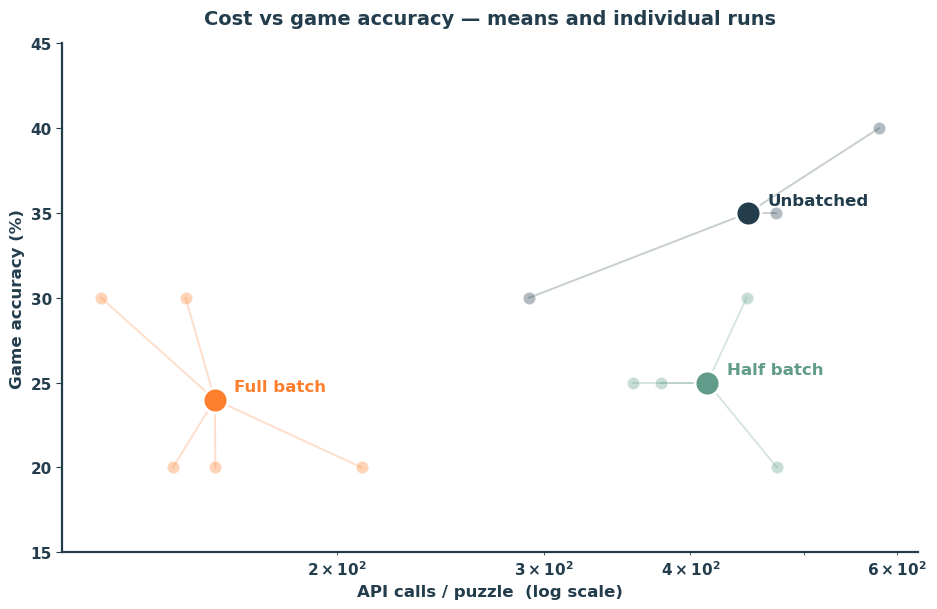

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 6.2))
for label in levels:
    s = stats[label]
    color = LEVEL_COLOR[label]
    runs_calls = s['calls_runs']
    runs_game  = s['game_runs']
    # individual runs
    ax.scatter(runs_calls, runs_game, s=80, color=color, alpha=0.35,
               edgecolor='white', linewidth=1.0, zorder=2)
    # mean point
    ax.scatter(s['calls_mean'], s['game_mean'], s=320, color=color,
               edgecolor='white', linewidth=2.0, zorder=4, label=f'{label} (mean)')
    # dotted lines from mean to each run for visual dispersion
    for cx, cy in zip(runs_calls, runs_game):
        ax.plot([s['calls_mean'], cx], [s['game_mean'], cy],
                color=color, alpha=0.25, linewidth=1.4, zorder=1)
    # label near mean
    ax.annotate(label, (s['calls_mean'], s['game_mean']),
                xytext=(14, 6), textcoords='offset points',
                fontsize=12, color=color, fontweight='bold')

ax.set_xscale('log')
ax.set_xlabel('API calls / puzzle  (log scale)')
ax.set_ylabel('Game accuracy (%)')
ax.set_title('Cost vs game accuracy — means and individual runs', pad=14)
ax.set_ylim(15, 45)
fig.tight_layout()
plt.show()

/var/folders/wf/xg1rm9bd57z7149b6plbcym80000gn/T/ipykernel_87996/2664463912.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=levels, widths=0.5, patch_artist=True,


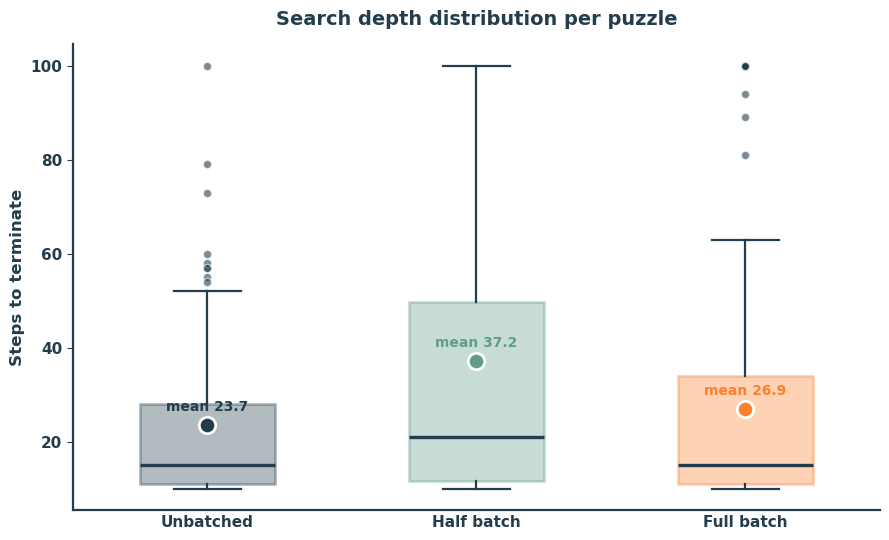

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
data = [list(np.concatenate([m['per_puzzle_steps'] for m in stats[l]['per_run']]))
        for l in levels]
bp = ax.boxplot(data, labels=levels, widths=0.5, patch_artist=True,
                medianprops={'color': CHARCOAL, 'linewidth': 2.4},
                whiskerprops={'color': CHARCOAL, 'linewidth': 1.6},
                capprops={'color': CHARCOAL, 'linewidth': 1.6},
                flierprops={'marker': 'o', 'markerfacecolor': CHARCOAL,
                            'markeredgecolor': 'white', 'markersize': 6, 'alpha': 0.6})
for patch, l in zip(bp['boxes'], levels):
    patch.set_facecolor(LEVEL_COLOR[l]); patch.set_alpha(0.35)
    patch.set_edgecolor(LEVEL_COLOR[l]); patch.set_linewidth(2)
for xi, l in enumerate(levels, start=1):
    mean_steps = stats[l]['steps_mean']
    ax.scatter(xi, mean_steps, color=LEVEL_COLOR[l], s=140, zorder=4,
               edgecolor='white', linewidth=2)
    ax.text(xi, mean_steps + 3, f'mean {mean_steps:.1f}',
            ha='center', fontsize=10, color=LEVEL_COLOR[l], fontweight='bold')
ax.set_ylabel('Steps to terminate')
ax.set_title('Search depth distribution per puzzle', pad=14)
fig.tight_layout()
plt.show()

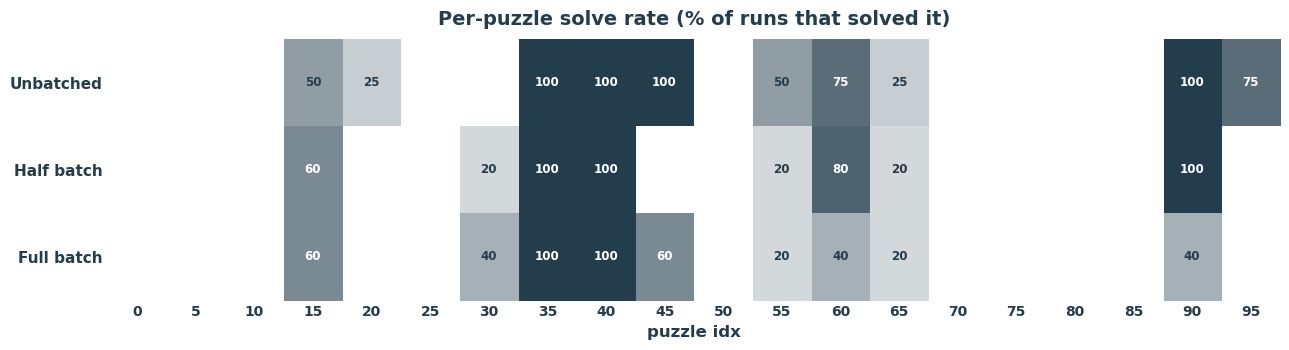

In [7]:
def solve_rate_per_idx(runs):
    """Returns {idx: fraction of runs that solved it}."""
    by_idx = {}
    for r in runs:
        for row in r['rows']:
            _, _, g = grid_metrics(row['grid'], row['ground_truth'])
            by_idx.setdefault(row['idx'], []).append(int(g > 0.5))
    return {i: sum(v)/len(v) for i, v in by_idx.items() if v}

rates = {l: solve_rate_per_idx(r) for l, r in
         [('Unbatched', unb_runs), ('Half batch', half_runs), ('Full batch', full_runs)]}
all_idx = sorted({i for d in rates.values() for i in d})
M = np.array([[rates[l].get(i, 0.0) for i in all_idx] for l in levels])

cmap = LinearSegmentedColormap.from_list('charcoal_fade', ['white', CHARCOAL])

fig, ax = plt.subplots(figsize=(13, 3.6))
im = ax.imshow(M, aspect='auto', cmap=cmap, vmin=0, vmax=1)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        if v > 0:
            ax.text(j, i, f'{int(v*100)}',
                    ha='center', va='center', fontsize=8.5,
                    color='white' if v > 0.5 else CHARCOAL,
                    fontweight='bold')
ax.set_yticks(range(len(levels))); ax.set_yticklabels(levels)
ax.set_xticks(range(len(all_idx))); ax.set_xticklabels([str(i) for i in all_idx], fontsize=10)
ax.set_xlabel('puzzle idx')
ax.tick_params(axis='x', length=0); ax.tick_params(axis='y', length=0)
for s in ('top', 'right', 'left', 'bottom'): ax.spines[s].set_visible(False)
ax.set_title('Per-puzzle solve rate (% of runs that solved it)', pad=10)
fig.tight_layout()
plt.show()

/var/folders/wf/xg1rm9bd57z7149b6plbcym80000gn/T/ipykernel_87996/1901681308.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.965))


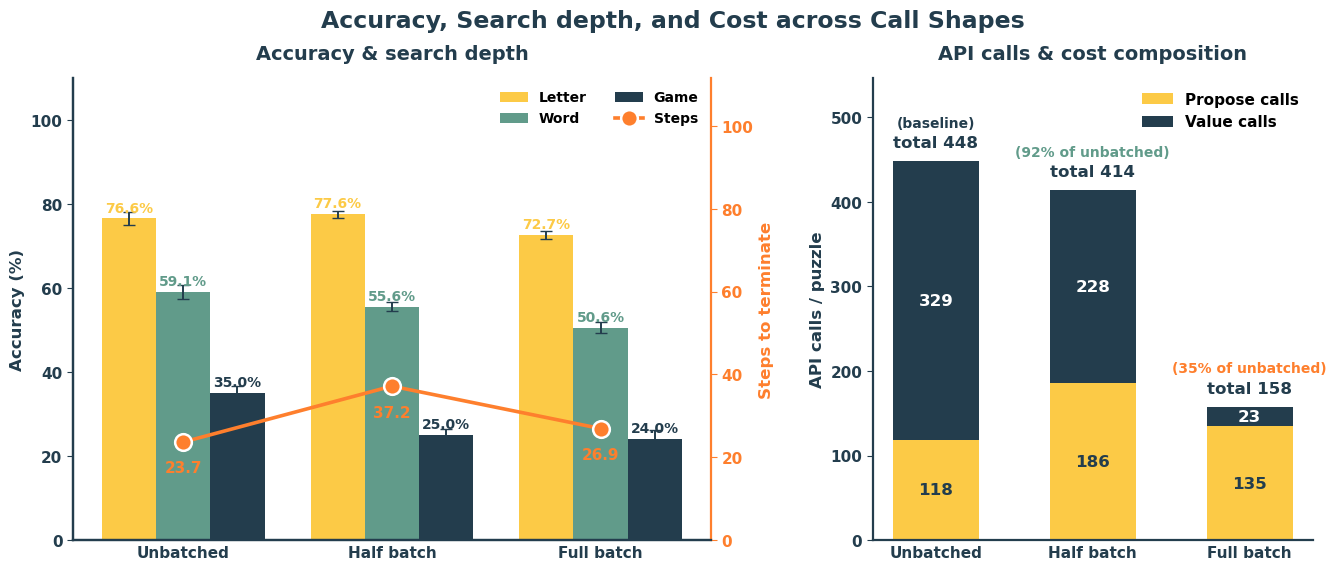

In [ ]:
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 1.0], wspace=0.30)
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])

# --- Left: accuracy grouped bars + steps as right-axis line ---
metric_specs = [
    ('letter', 'Letter', GOLDEN),
    ('word',   'Word',   SEAGRASS),
    ('game',   'Game',   CHARCOAL),
]
x = np.arange(len(levels))
group_width = 0.78
bar_width = group_width / len(metric_specs)

for i, (key, label, color) in enumerate(metric_specs):
    means = [stats[l][f'{key}_mean'] for l in levels]
    ses   = [stats[l][f'{key}_se']   for l in levels]
    offset = (i - (len(metric_specs)-1)/2) * bar_width
    bars = axA.bar(x + offset, means, bar_width, color=color, label=label,
                   edgecolor='none', yerr=ses, capsize=4,
                   error_kw={'elinewidth': 1.4, 'ecolor': CHARCOAL})
    for rect, mean in zip(bars, means):
        axA.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 1.6,
                 f'{mean:.1f}%', ha='center', fontsize=10,
                 color=color, fontweight='bold')

axA.set_xticks(x)
axA.set_xticklabels(levels)
axA.set_ylabel('Accuracy (%)')
axA.set_ylim(0, 110)
axA.set_title('Accuracy & search depth', pad=14)

# Twin axis: steps line in pumpkin. Generous upper limit pushes the line
# into the lower band of the plot, well below the bar tops.
axA2 = axA.twinx()
axA2.spines['right'].set_visible(True)
axA2.spines['right'].set_color(PUMPKIN)
axA2.spines['top'].set_visible(False)
steps_means = [stats[l]['steps_mean'] for l in levels]
steps_max   = max(steps_means)
axA2.plot(x, steps_means, color=PUMPKIN, marker='o', linewidth=2.6,
          markersize=12, markeredgecolor='white', markeredgewidth=1.8,
          zorder=5, label='Steps')
for xi, s in zip(x, steps_means):
    axA2.annotate(f'{s:.1f}', (xi, s),
                  xytext=(0, -22), textcoords='offset points',
                  ha='center', fontsize=11, color=PUMPKIN, fontweight='bold')
axA2.set_ylabel('Steps to terminate', color=PUMPKIN)
axA2.tick_params(axis='y', colors=PUMPKIN)
axA2.set_ylim(0, steps_max * 3.0)

# Combined legend: inside plot, upper-right where bars don't reach 100%.
handles_a, labels_a = axA.get_legend_handles_labels()
handles_b, labels_b = axA2.get_legend_handles_labels()
axA.legend(handles_a + handles_b, labels_a + labels_b,
           loc='upper right', ncol=2, fontsize=10)

# --- Right: cost composition (propose vs value) ---
def call_breakdown(runs):
    propose, value = [], []
    for r in runs:
        for row in r['rows']:
            propose.append(row.get('llm_calls_propose', 0))
            value.append(row.get('llm_calls_value', 0))
    return statistics.mean(propose), statistics.mean(value)

br = {
    'Unbatched':  call_breakdown(unb_runs),
    'Half batch': call_breakdown(half_runs),
    'Full batch': call_breakdown(full_runs),
}
propose_vals = [br[l][0] for l in levels]
value_vals   = [br[l][1] for l in levels]
totals       = [p + v for p, v in zip(propose_vals, value_vals)]
unb_total    = totals[0]

axB.bar(x, propose_vals,                    color=GOLDEN,   label='Propose calls', edgecolor='none', width=0.55)
axB.bar(x, value_vals, bottom=propose_vals, color=CHARCOAL, label='Value calls',   edgecolor='none', width=0.55)

ymax = max(totals) * 1.22
for xi, p, v, total in zip(x, propose_vals, value_vals, totals):
    if p > ymax * 0.04:
        axB.text(xi, p/2, f'{p:.0f}', ha='center', va='center',
                 color=CHARCOAL, fontsize=12, fontweight='bold')
    if v > ymax * 0.04:
        axB.text(xi, p + v/2, f'{v:.0f}', ha='center', va='center',
                 color='white', fontsize=12, fontweight='bold')
    ratio = total / unb_total
    axB.text(xi, total + ymax*0.03, f'total {total:.0f}',
             ha='center', fontsize=12, color=CHARCOAL, fontweight='bold')
    axB.text(xi, total + ymax*0.075,
             f'({ratio*100:.0f}% of unbatched)' if ratio < 0.999 else '(baseline)',
             ha='center', fontsize=10, color=LEVEL_COLOR[levels[xi]], fontweight='bold')

axB.set_xticks(x)
axB.set_xticklabels(levels)
axB.set_ylabel('API calls / puzzle')
axB.set_ylim(0, ymax)
axB.set_title('API calls & cost composition', pad=14)
axB.legend(loc='upper right')

fig.suptitle('Accuracy, Search depth, and Cost across Call Shapes',
             fontsize=17, fontweight='bold', color=CHARCOAL, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.965))
plt.show()